In [14]:
# 🌿 Spinach Leaf Disease Classification using CNN

## 1. Imports & Configuration

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import load_img, img_to_array

DATA_DIR = "Spinach_Dataset"
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 50
NUM_CLASSES = 3
RANDOM_STATE = 42

In [15]:
## 2. Load Dataset

images = []
labels = []

class_names = sorted(os.listdir(DATA_DIR))
class_to_index = {cls: idx for idx, cls in enumerate(class_names)}

for cls in class_names:
    cls_path = os.path.join(DATA_DIR, cls)
    for img_name in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img_name)
        img = load_img(img_path, target_size=IMAGE_SIZE)
        img = img_to_array(img)
        images.append(img)
        labels.append(class_to_index[cls])

images = np.array(images)
labels = np.array(labels)

print("Classes:", class_names)
print("Total images:", len(images))

## 3. Train / Validation / Test Split

X_temp, X_test, y_temp, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=RANDOM_STATE, stratify=labels
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", len(X_train))
print("Validation:", len(X_val))
print("Test:", len(X_test))

Classes: ['cercospora_leaf_spot', 'healthly', 'powedry_mildew']
Total images: 378
Train: 241
Validation: 61
Test: 76


In [16]:

## 4. TensorFlow Datasets


train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds   = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds  = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds   = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds  = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


In [17]:
## 5. Data Augmentation

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])


In [18]:
## 6. CNN Architecture

model = models.Sequential([
    layers.InputLayer(input_shape=IMAGE_SIZE + (3,)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.summary()

C:\Users\tshep\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,452,611 (13.17 MB)

 Trainable params: 3,452,611 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
## 7. Compile & Train with Early Stopping

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping]
)

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 403ms/step - accuracy: 0.7884 - loss: 0.5600 - val_accuracy: 0.6885 - val_loss: 0.7635
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 385ms/step - accuracy: 0.7718 - loss: 0.5340 - val_accuracy: 0.6393 - val_loss: 0.8668
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 381ms/step - accuracy: 0.8008 - loss: 0.4999 - val_accuracy: 0.7377 - val_loss: 0.8318
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 366ms/step - accuracy: 0.8008 - loss: 0.4559 - val_accuracy: 0.7377 - val_loss: 0.8176
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 386ms/step - accuracy: 0.7635 - loss: 0.5530 - val_accuracy: 0.6230 - val_loss: 0.9936
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 364ms/step - accuracy: 0.7801 - loss: 0.4828 - val_accuracy: 0.6721 - val_loss: 0.9888


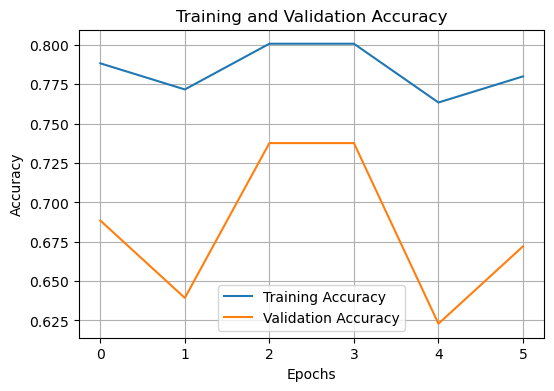

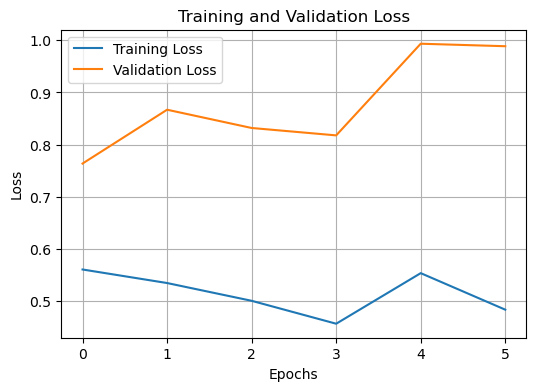

In [33]:
## 8. Training & Validation Curves

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
## 9. Test Evaluation

test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")



5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.6974 - loss: 0.6910 
Test Accuracy: 0.6974
Test Loss: 0.6910


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 372ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


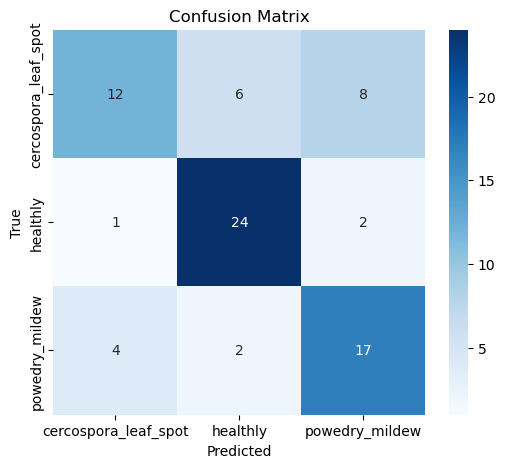

                      precision    recall  f1-score   support

cercospora_leaf_spot       0.71      0.46      0.56        26
            healthly       0.75      0.89      0.81        27
      powedry_mildew       0.63      0.74      0.68        23

            accuracy                           0.70        76
           macro avg       0.70      0.70      0.68        76
        weighted avg       0.70      0.70      0.69        76



In [35]:

## 10. Confusion Matrix & Classification Report

y_true, y_pred = [], []

for x, y in test_ds:
    preds = model.predict(x)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(y.numpy())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 162ms/step


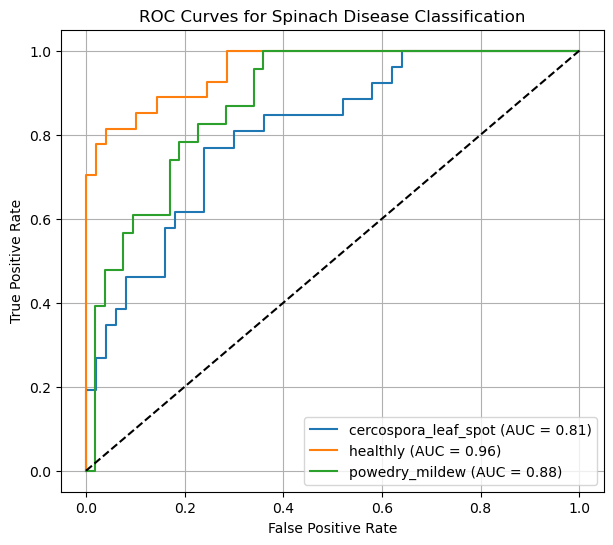

In [36]:
## 11. ROC Curves (Multiclass)


y_true_bin = label_binarize(y_true, classes=[0,1,2])
y_score = model.predict(test_ds)

plt.figure(figsize=(7,6))

for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Spinach Disease Classification")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()


# 12. Transfer Learning with ResNet50

## 12.1 Motivation

The baseline CNN showed moderate performance, particularly confusion between disease classes. To improve feature extraction, a deep pretrained network (ResNet50) is introduced using transfer learning. ResNet architectures are effective at learning hierarchical visual features and often outperform shallow CNNs on small datasets.


In [37]:
### 12.2 ResNet50 Model Definition

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# Data pipeline with ResNet preprocessing
train_ds_resnet = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds_resnet   = val_ds.map(lambda x, y: (preprocess_input(x), y))
test_ds_resnet  = test_ds.map(lambda x, y: (preprocess_input(x), y))

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=IMAGE_SIZE + (3,)
)

base_model.trainable = False  # Freeze pretrained layers

resnet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

resnet_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [38]:
### 12.3 Compile and Train ResNet Model


resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

resnet_early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

resnet_history = resnet_model.fit(
    train_ds_resnet,
    validation_data=val_ds_resnet,
    epochs=EPOCHS,
    callbacks=[resnet_early_stopping]
)



Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5062 - loss: 1.1908 - val_accuracy: 0.7705 - val_loss: 0.6567
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 812ms/step - accuracy: 0.7386 - loss: 0.6162 - val_accuracy: 0.7213 - val_loss: 0.6303
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 834ms/step - accuracy: 0.8340 - loss: 0.4254 - val_accuracy: 0.7049 - val_loss: 0.5901
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 845ms/step - accuracy: 0.8797 - loss: 0.2792 - val_accuracy: 0.8197 - val_loss: 0.4204
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 820ms/step - accuracy: 0.9004 - loss: 0.2664 - val_accuracy: 0.8361 - val_loss: 0.3756
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 805ms/step - accuracy: 0.9378 - loss: 0.1980 - val_accuracy: 0.8525 - val_loss: 0.3426
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 796ms/step - accuracy: 0.9710 - loss: 0.1168 - val_accuracy: 0.8852 - val_loss: 0.3706
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 811ms/step - accuracy: 0.9876 - loss: 0.1009 - val_accurac

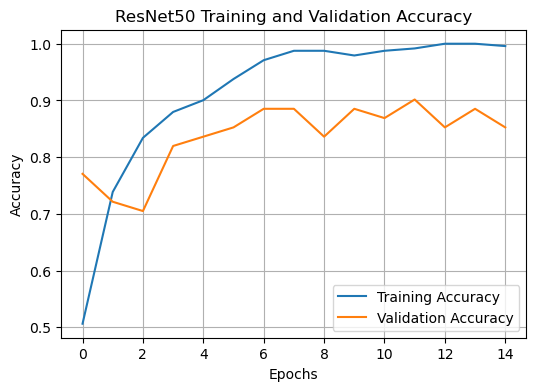

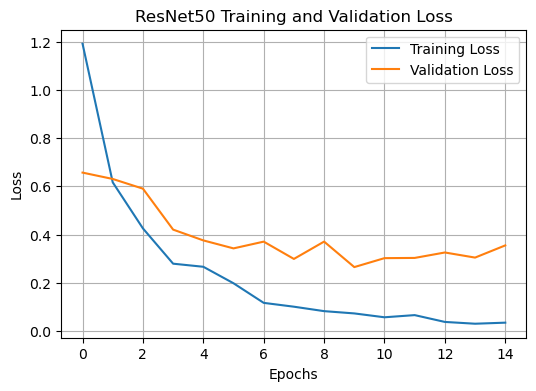

In [39]:
### 12.4 Training vs Validation Curves (ResNet50)

plt.figure(figsize=(6,4))
plt.plot(resnet_history.history['accuracy'], label='Training Accuracy')
plt.plot(resnet_history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(resnet_history.history['loss'], label='Training Loss')
plt.plot(resnet_history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [40]:
### 12.5 Test Evaluation (ResNet50)

resnet_test_loss, resnet_test_accuracy = resnet_model.evaluate(test_ds_resnet)
print(f"ResNet50 Test Accuracy: {resnet_test_accuracy:.4f}")
print(f"ResNet50 Test Loss: {resnet_test_loss:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 617ms/step - accuracy: 0.8553 - loss: 0.3756
ResNet50 Test Accuracy: 0.8553
ResNet50 Test Loss: 0.3756


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 780ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 796ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


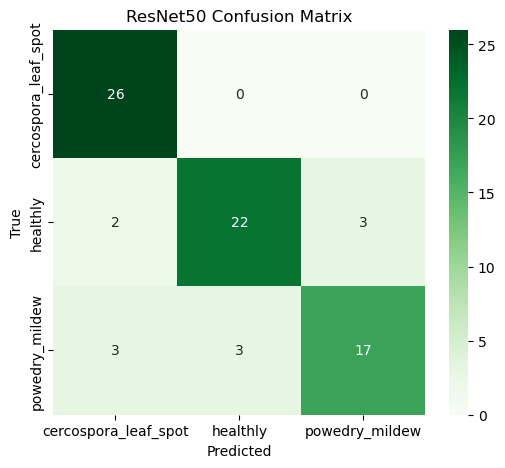

                      precision    recall  f1-score   support

cercospora_leaf_spot       0.84      1.00      0.91        26
            healthly       0.88      0.81      0.85        27
      powedry_mildew       0.85      0.74      0.79        23

            accuracy                           0.86        76
           macro avg       0.86      0.85      0.85        76
        weighted avg       0.86      0.86      0.85        76



In [41]:
### 12.6 Confusion Matrix (ResNet50)

y_true_resnet, y_pred_resnet = [], []

for x, y in test_ds_resnet:
    preds = resnet_model.predict(x)
    y_pred_resnet.extend(np.argmax(preds, axis=1))
    y_true_resnet.extend(y.numpy())

cm_resnet = confusion_matrix(y_true_resnet, y_pred_resnet)

plt.figure(figsize=(6,5))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ResNet50 Confusion Matrix")
plt.show()

print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names))

5/5 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step  


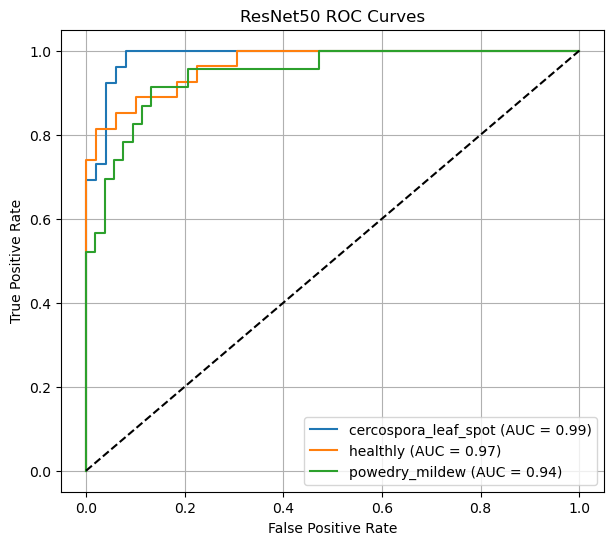

In [42]:

### 12.7 ROC Curves (ResNet50)
y_true_bin_resnet = label_binarize(y_true_resnet, classes=[0,1,2])
y_score_resnet = resnet_model.predict(test_ds_resnet)

plt.figure(figsize=(7,6))
for i, cls in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_true_bin_resnet[:, i], y_score_resnet[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ResNet50 ROC Curves")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## 13. Model Comparison Summary

| Model         | Test Accuracy | Key Observation                             |
| ------------- | ------------- | ------------------------------------------- |
| Custom CNN    | 0.70         | Strong healthy detection, disease confusion |
| ResNet50 (TL) | 0.86    | Improved feature discrimination   

In [43]:
## 14. Save ResNet Model
resnet_model.save("spinach_leaf_disease_cnn_vs_resnet50.keras")